
## **Step 1: Understanding the Encoder-Decoder Architecture**

The Encoder-Decoder model is a neural network architecture designed for sequence-to-sequence tasks. It consists of:
1. **Encoder**: Processes the input sequence and encodes it into a fixed-length context vector (hidden states).
2. **Decoder**: Generates the output sequence step-by-step based on the context vector and its previous outputs.

For example, in machine translation:
- Input: "How are you?" (English)
- Output: "Wie geht es dir?" (German)


## **Step 2: Preparing the Environment**


8. Implement an encoder-decoder model for a sequence-to-sequence task, such as translating text from one language to another.

In [ ]:
!pip install tensorflow


---

## **Step 3: Import Libraries**


In [ ]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense
import matplotlib.pyplot as plt


---

## **Step 4: Define Model Parameters**

Set key parameters for the model:


In [ ]:
latent_dim = 256  # Dimensionality of LSTM hidden states
num_encoder_tokens = 100  # Size of input vocabulary
num_decoder_tokens = 100  # Size of output vocabulary
max_encoder_seq_length = 10  # Max length of input sequences
max_decoder_seq_length = 10  # Max length of output sequences



---

## **Step 5: Define the Encoder-Decoder Model**

### Encoder:
The encoder processes the input sequence and outputs its hidden states.


In [ ]:
encoder_inputs = Input(shape=(None, num_encoder_tokens))
encoder_lstm = LSTM(latent_dim, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]



### Decoder:
The decoder generates output sequences using the encoder's states as initial states.


In [ ]:
decoder_inputs = Input(shape=(None, num_decoder_tokens))
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = Dense(num_decoder_tokens, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)


model = Model([encoder_inputs, decoder_inputs], decoder_outputs)




---

## **Step 6: Compile the Model**

Compile the model with categorical crossentropy loss and Adam optimizer.


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])




---

## **Step 7: Generate Dummy Data**

Create random data for demonstration purposes:


In [ ]:
num_samples = 1000

X1_train = np.random.rand(num_samples, max_encoder_seq_length, num_encoder_tokens)  # Encoder input data
X2_train = np.random.rand(num_samples, max_decoder_seq_length, num_decoder_tokens)  # Decoder input data
y_train = np.random.rand(num_samples, max_decoder_seq_length, num_decoder_tokens)   # Target data (shifted decoder outputs)




---

## **Step 8: Train the Model**

Train the model using dummy data:


In [ ]:

history = model.fit([X1_train, X2_train], y_train, batch_size=64, epochs=10)



Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.0102 - loss: 237.1714
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.0098 - loss: 259.7063
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.0117 - loss: 260.5147
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.0101 - loss: 260.4238
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.0091 - loss: 260.1358
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.0103 - loss: 260.2254
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.0108 - loss: 260.3054
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.0100 - loss: 259.9970
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.0096 - loss: 260.0452
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.0094 - loss: 259.9563



---

## **Step 9: Visualize Training Performance**

Plot training loss over epochs:


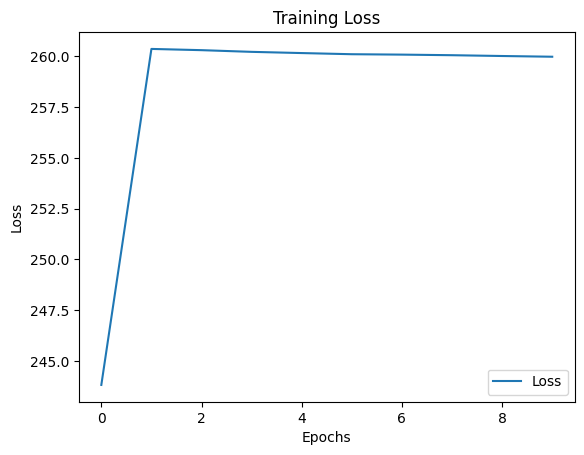

In [ ]:
plt.plot(history.history['loss'], label='Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()



---

## **Step 10: Define Inference Models**

To use the trained model for predictions:
1. Define an encoder model to output hidden states.
2. Define a decoder model to generate sequences step-by-step.


In [ ]:

### Encoder Model:

encoder_model = Model(encoder_inputs, encoder_states)


### Decoder Model:

decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_outputs, state_h, state_c = decoder_lstm(
    decoder_inputs, initial_state=decoder_states_inputs)
decoder_states = [state_h, state_c]
decoder_outputs = decoder_dense(decoder_outputs)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs] + decoder_states)




---

## **Step 11: Write a Function for Decoding Sequences**

This function generates output sequences given an input sequence.


In [ ]:
def decode_sequence(input_seq):
    states_value = encoder_model.predict(input_seq)

    target_seq = np.zeros((1, 1, num_decoder_tokens))
    target_seq[0, 0, 0] = 1  # Start token index

    stop_condition = False
    decoded_sentence = []
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)

        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        decoded_sentence.append(sampled_token_index)

        if sampled_token_index == 2 or len(decoded_sentence) > max_decoder_seq_length:  # End token index is assumed to be '2'
            stop_condition = True

        target_seq[0, 0] = output_tokens[0, -1]
        states_value = [h, c]

    return decoded_sentence



---

## **Step 12: Test the Model**

Use dummy data to test predictions:


In [ ]:
input_seq_example = np.random.rand(1, max_encoder_seq_length, num_encoder_tokens)
translated_sequence = decode_sequence(input_seq_example)
print("Translated Sequence:", translated_sequence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Translated Sequence: [np.int64(62), np.int64(62), np.int64(62), np.int64(62), np.int64(62), np.int64(62), np.int64(62), np.int64(62), np.int64(62), np.int64(62), np.int64(62)]


In [ ]:

print("Encoder Model:")
print(encoder_model.summary())
print("\nDecoder Model:")
print(decoder_model.summary())


Encoder Model:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, None, 100)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ [(None, 256), (None, 256),  │         365,568 │
│                                      │ (None, 256)]                │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 365,568 (1.39 MB)

 Trainable params: 365,568 (1.39 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, None, 100)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_2             │ (None, 256)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_3             │ (None, 256)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ [(None, None, 256),    │        365,568 │ input_layer_1[0][0],   │
│                           │ (None, 256), (None,    │                │ input_layer_2[0][0],   │
│                           │ 256)]                  │                │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, None, 100)      │         25,700 │ lstm_1[1][0]           │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 391,268 (1.49 MB)

 Trainable params: 391,268 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense

# Sample dataset (English-French pairs)
input_texts = ["hello", "how are you", "good morning", "thank you", "good night"]
target_texts = ["bonjour", "comment ça va", "bonjour", "merci", "bonne nuit"]

# Character set extraction
input_characters = sorted(set("".join(input_texts)))
target_characters = sorted(set("".join(target_texts)))
num_encoder_tokens = len(input_characters)
num_decoder_tokens = len(target_characters)
max_encoder_seq_length = max([len(txt) for txt in input_texts])
max_decoder_seq_length = max([len(txt) for txt in target_texts])

# Character indices
input_token_index = {char: i for i, char in enumerate(input_characters)}
target_token_index = {char: i for i, char in enumerate(target_characters)}
reverse_target_char_index = {i: char for char, i in target_token_index.items()}

# Prepare training data
encoder_input_data = np.zeros((len(input_texts), max_encoder_seq_length, num_encoder_tokens), dtype="float32")
decoder_input_data = np.zeros((len(input_texts), max_decoder_seq_length, num_decoder_tokens), dtype="float32")
decoder_target_data = np.zeros((len(input_texts), max_decoder_seq_length, num_decoder_tokens), dtype="float32")

for i, (input_text, target_text) in enumerate(zip(input_texts, target_texts)):
    for t, char in enumerate(input_text):
        encoder_input_data[i, t, input_token_index[char]] = 1.0
    for t, char in enumerate(target_text):
        decoder_input_data[i, t, target_token_index[char]] = 1.0
        if t > 0:
            decoder_target_data[i, t - 1, target_token_index[char]] = 1.0

# Model architecture
latent_dim = 256
encoder_inputs = Input(shape=(None, num_encoder_tokens))
encoder_lstm = LSTM(latent_dim, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

decoder_inputs = Input(shape=(None, num_decoder_tokens))
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = Dense(num_decoder_tokens, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit([encoder_input_data, decoder_input_data], decoder_target_data, batch_size=64, epochs=100, validation_split=0.2)

# Encoder model for inference
encoder_model = Model(encoder_inputs, encoder_states)

# Decoder model for inference
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]
decoder_outputs, state_h, state_c = decoder_lstm(decoder_inputs, initial_state=decoder_states_inputs)
decoder_states = [state_h, state_c]
decoder_outputs = decoder_dense(decoder_outputs)
decoder_model = Model([decoder_inputs] + decoder_states_inputs, [decoder_outputs] + decoder_states)

def decode_sequence(input_seq):
    states_value = encoder_model.predict(input_seq)
    target_seq = np.zeros((1, 1, num_decoder_tokens))
    target_seq[0, 0, target_token_index[' ']] = 1.0
    decoded_sentence = ''
    for _ in range(max_decoder_seq_length):
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_char = reverse_target_char_index[sampled_token_index]
        decoded_sentence += sampled_char
        if sampled_char == '\n':
            break
        target_seq = np.zeros((1, 1, num_decoder_tokens))
        target_seq[0, 0, sampled_token_index] = 1.0
        states_value = [h, c]
    return decoded_sentence

# Example usage
input_test_seq = encoder_input_data[0:1]
translated_text = decode_sequence(input_test_seq)
print("Translated text:", translated_text)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.0577 - loss: 1.4535 - val_accuracy: 0.0769 - val_loss: 1.8781
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 615ms/step - accuracy: 0.0962 - loss: 1.4425 - val_accuracy: 0.0769 - val_loss: 1.8724
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.1923 - loss: 1.4309 - val_accuracy: 0.0769 - val_loss: 1.8653
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.2308 - loss: 1.4183 - val_accuracy: 0.0769 - val_loss: 1.8560
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.2692 - loss: 1.4036 - val_accuracy: 0.2308 - val_loss: 1.8429
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.2692 - loss: 1.3858 - val_accuracy: 0.3846 - val_loss: 1.8237
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.3269 - loss: 1.3627 - val_accuracy: 0.3846 - val_loss: 1.7954
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.3846 - loss: 1.3313 - val_accuracy: 0.3846 - val_